In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec
import matplotlib.colors as colors
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import cm
from matplotlib.patches import Patch

import os
import scanpy as sc

import seaborn as sns
import snapatac2 as snap

snap.__version__



plt.rcParams['figure.dpi'] = 167
plt.rcParams['font.size'] = 14
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [font for font in 'Liberation Sans, DejaVu Sans, Arial, Helvetica, Lucida Grande, Verdana, Geneva, Lucid, Avant Garde, sans-serif'.split(', ')] 
plt.rcParams['mathtext.fontset'] = 'stixsans'

plt.rcParams['axes.linewidth'] = 1
plt.rcParams['grid.linewidth'] = 1
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 6




/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
cat_colors_list = [ '#263238','#2E5BFF', "#D4AF37", '#D81B60', '#558B2F', '#7B1FA2', '#E65100']  # ,   '#94A3B8' 
unique_categories = ['common',  'SADE unique', 'CR unique', 'TSS unique',  'SADE+CR, not TSS', 'SADE+TSS, not CR', 'CR+TSS, not SADE', ]
cat_colors_map = dict(zip(unique_categories, cat_colors_list))    


jitter_width = 0.25
position_offset = [0] + [-jitter_width] * 3 + [jitter_width] * 3  # Adjust offsets for each category
cat_position_map = dict(zip(unique_categories, position_offset))


scanpy_colors = [    
    '#1f77b4',
    '#ff7f0e', 
    '#2ca02c',
    '#d62728', 
    '#9467bd', 
    '#8c564b', 
    '#e377c2', 
    '#bcbd22', 
    '#17becf', 
    '#c7c7c7', 
    '#ffbb78',
    '#98df8a']
scanpy_cluster = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']
scanpy_color_map = dict(zip(scanpy_cluster, scanpy_colors))

## Load Data

In [4]:
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
Union_cell_info_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_all_info.tsv')
union_cell_info = pd.read_csv(Union_cell_info_file, sep='\t', index_col=0)
union_cell_info['index'] = union_cell_info.index.map(lambda x: x + '-1')

union_cell_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris,_3set_identified_by_atac,index
atac_bc,,,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO,common,AAACAAGCAAGTTAGT-1
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO,common,AAACAAGCATTTCTTC-1


In [6]:

data = sc.read_h5ad(os.path.join(Union_cell_subdir, '_SNAPataC_analysis', 'binnedGenome_all_unioncells.h5ad'))


In [7]:
data

AnnData object with n_obs × n_vars = 2384 × 6062095
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'rna_pass_CR', 'atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS', '_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', '_3set_identified_by_atac', 'DNA_debris', 'amulet_doublet_atac', 'leiden_RNA_scVI', 'total_fragments', 'FRIP_raw_peaks', 'FRIP_entropy_peaks', 'FRIP_tss_peaks', 'FRIP_frip_peaks', 'nucleosome_signal', 'tsse', 'leiden', 'leiden_scanpy'
    var: 'count', 'selected'
    uns: 'DNA_debris_colors', 'TSS_profile', '_3set_identified_by_atac_colors', 'amulet_doublet_atac_colors', 'frac_overlap_TSS', 'leiden_RNA_scVI_colors', 'leiden_colors', 'leiden_scanpy', 'leiden_scanpy_colors', 'library_tsse', 'reference_sequences', 'spectral_eigenvalue'
    obsm: 'X_spectral', 'X_umap', 'fragment_paired'
    obsp: 'distances'

# TSSe 

In [18]:
ArchR_tsse_score_file = os.path.join(entropy_dir,  '_ArchR_TSS/QualityControl/VIB_10xmultiome_2_Metadata.tsv')
ArchR_tsse_score = pd.read_csv(ArchR_tsse_score_file, sep='\t', index_col=0)
ArchR_tsse_score['atac_bc'] = ArchR_tsse_score.index.str.replace('VIB_10xmultiome_2#', '', regex=False)
ArchR_tsse_score.index = ArchR_tsse_score['atac_bc']
ArchR_tsse_score.head(2)

,nFrags,nMonoFrags,nDiFrags,nMultiFrags,TSSEnrichment,ReadsInTSS,Keep,ReadsInPromoter,PromoterRatio,ReadsInBlacklist,BlacklistRatio,atac_bc
atac_bc,,,,,,,,,,,,
GGGTTGCAGCTCAAGG-1,93652,47018,37344,9290,20.827,61970,1,55796,0.297890,1417,0.007565,GGGTTGCAGCTCAAGG-1
GTCATTTAGAGAGCAA-1,92024,24025,55290,12709,12.683,17927,1,17285,0.093916,839,0.004559,GTCATTTAGAGAGCAA-1


In [24]:
data.obs['ArchR_tsse_score'] =data.obs.index.map(ArchR_tsse_score['TSSEnrichment'])

In [38]:
data.obs['ArchR_tsse_score'].isna().sum()

np.int64(213)

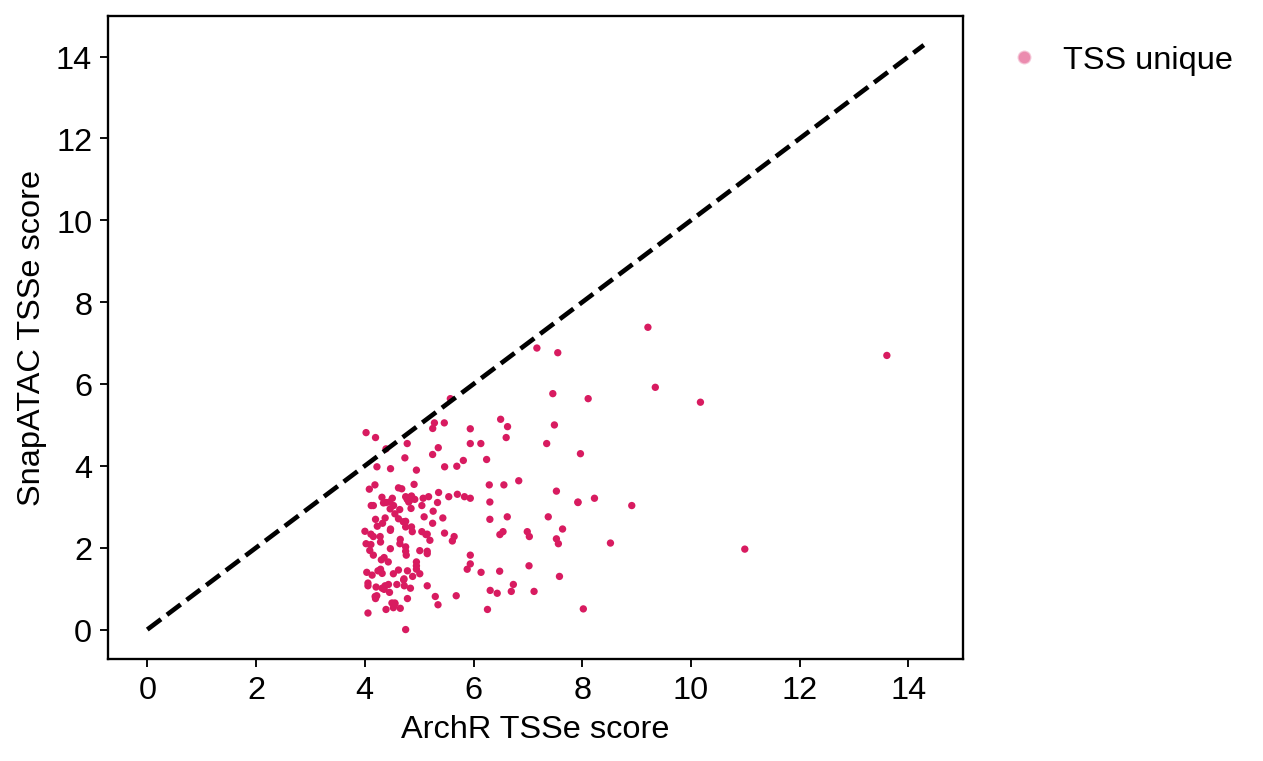

In [46]:
fig, ax = plt.subplots(figsize=(6.6, 5))

TSSe_unique_index = data.obs['_3set_identified_by_atac'] == 'TSS unique'
_= ax.scatter(data.obs.loc[TSSe_unique_index, 'ArchR_tsse_score'], data.obs.loc[TSSe_unique_index, 'tsse'], alpha=1, s=10, 
              c=data.obs.loc[TSSe_unique_index, '_3set_identified_by_atac'].map(cat_colors_map), edgecolor='none')
max_range = max(data.obs.loc[TSSe_unique_index, 'ArchR_tsse_score'].max(), data.obs.loc[TSSe_unique_index, 'tsse'].max()) * 1.05
ax.plot([0, max_range], [0, max_range], 'k--', lw=2)
ax.set_xlabel('ArchR TSSe score')
ax.set_ylabel('SnapATAC TSSe score')

handles = [Line2D([0], [0], color='w', marker="o", markerfacecolor=cat_colors_map[c],  alpha=0.5, label=c) for c in ['TSS unique']]
ax.legend(handles=handles, frameon=False, loc='upper left', bbox_to_anchor=(1., 1), handletextpad=0.2)